In [13]:
## load the koo-model ISM (saturation-mutagenesis) maps for a random sequence
# gradient-corrected (mean-centered across channels) — analog of hypothetical DeepLIFT
# high-activity HepG2 example: HepG2_activating_0
import h5py
import numpy as np
import matplotlib.pyplot as plt
import logomaker
import pandas as pd

seam_dir = "/grid/koo/home/pmantill/projects/Virtual_Experiments/MoConSwap_mpra/SEAM_jointlib900/results"
condition, seq_idx = "HepG2_activating", 0

with h5py.File(f"{seam_dir}/ism_var200/HepG2/{condition}_{seq_idx}.h5") as f:
    attributions = f["ism_centered"][:]   # (N, 200, 4) ISM, mean-centered across channels
    predictions  = f["predictions"][:]    # (N,) self-prediction of each base sequence

with h5py.File(f"{seam_dir}/mutagenesis_lib_var200/{condition}_{seq_idx}.h5") as f:
    sequences   = f["sequences"][:]       # (N, 200, 4); index 0 is WT
    wt_sequence = f["wt_sequence"][:]     # (230, 4) with 15bp adapters

wt_onehot = wt_sequence[15:215]           # variable region matches attributions axis
wt_attr   = attributions[0]               # WT attribution map (ISM-centered)

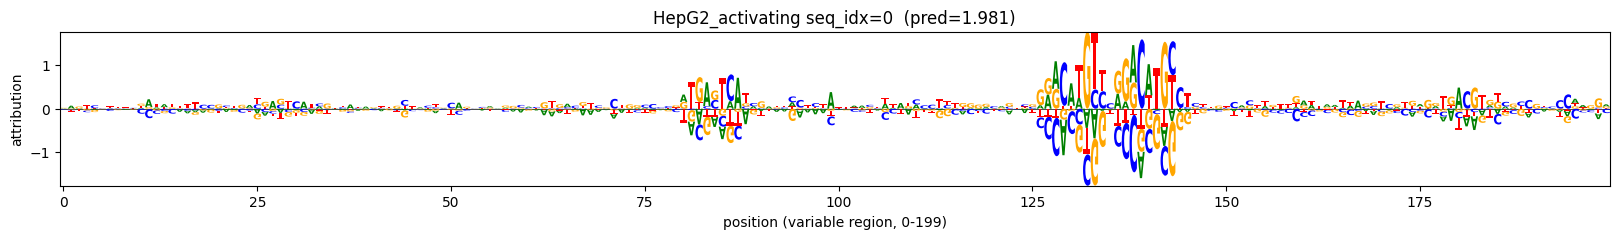

In [14]:
## visualize wt logo
wt_logo = pd.DataFrame(wt_attr, columns=list("ACGT"))

fig, ax = plt.subplots(figsize=(20, 2))
logomaker.Logo(wt_logo, ax=ax)
ax.set_xlabel("position (variable region, 0-199)")
ax.set_ylabel("attribution")
ax.set_title(f"{condition} seq_idx={seq_idx}  (pred={predictions[0]:.3f})")
plt.show()

In [15]:
print(f"{attributions.shape[0]:,} attribution maps  |  shape per map: {attributions.shape[1:]}")

25,000 attribution maps  |  shape per map: (200, 4)


In [16]:
## VB-GMM setup — K components share one Dirichlet; index 0 is "bg" (init at global μ, per-dim σ²)
from scipy.special import digamma, gammaln, logsumexp

X  = attributions.reshape(attributions.shape[0], -1)      # (N, 4L)
X2 = X**2
N, D = X.shape
print(f"N={N:,}  D={D}  (=4*{D//4})")

def log_gauss_diag(X, mu, log_var, X2=None):
    if X2 is None: X2 = X**2
    precision = np.exp(-log_var)
    log_norm  = -0.5 * (np.log(2*np.pi) + log_var).sum(-1)
    mahal     = (X2 @ precision.T
                 - 2 * X @ (mu * precision).T
                 + (mu**2 * precision).sum(-1))
    return log_norm - 0.5 * mahal

def kl_dirichlet(alpha, alpha0, Elog_pi):
    K = len(alpha)
    return (gammaln(alpha.sum()) - gammaln(alpha).sum()
            - gammaln(K * alpha0) + K * gammaln(alpha0)
            + ((alpha - alpha0) * Elog_pi).sum())

def elbo_from_logunnorm(log_unnorm, alpha, alpha0, Elog_pi):
    return logsumexp(log_unnorm, axis=1).sum() - kl_dirichlet(alpha, alpha0, Elog_pi)

def label(k):
    return "bg" if k == BG_IDX else str(k)

K, alpha0 = 100, 1e-6
BG_IDX    = 0
rng       = np.random.default_rng(0)

# random-data init for the K-1 numbered clusters, then overwrite slot 0 with BG init
mu              = X[rng.choice(N, K, replace=False)].copy()
log_var         = np.full((K, D), np.log(X.var(0).mean() + 1e-8))
mu[BG_IDX]      = X.mean(0)                          # global mean
log_var[BG_IDX] = np.log(X.var(0) + 1e-8)            # global per-dim variance

alpha = np.full(K, alpha0 + N / K)                   # q(pi) ~ uniform
print(f"K={K} (slot {BG_IDX} = bg)  alpha0={alpha0}")

N=25,000  D=800  (=4*200)
K=100 (slot 0 = bg)  alpha0=1e-06


converged in 200 iters  |  active: 85/100  |  bg active: True  |  ELBO: 30225702.605


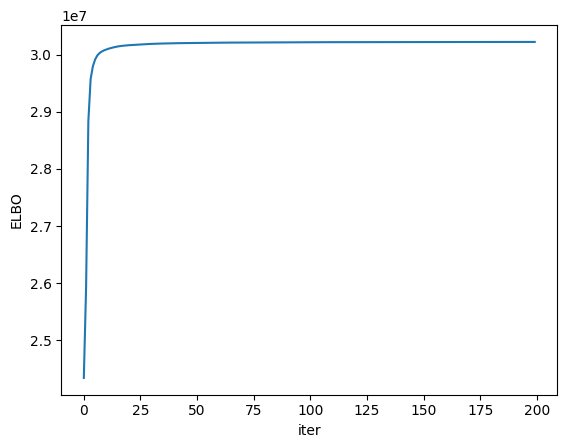


WT (seq_idx=0):  hard = 91  |  P(hard)=1.000  |  P(bg)=0.000  |  Nk(hard)=353.9


In [17]:
## VB-EM to convergence — BG (slot 0) μ/σ² frozen at init; only its α updates
losses = []
for it in range(200):
    Elog_pi    = digamma(alpha) - digamma(alpha.sum())
    log_unnorm = log_gauss_diag(X, mu, log_var, X2=X2) + Elog_pi
    log_r      = log_unnorm - logsumexp(log_unnorm, axis=1, keepdims=True)
    r          = np.exp(log_r)

    losses.append(elbo_from_logunnorm(log_unnorm, alpha, alpha0, Elog_pi))

    Nk      = r.sum(0)
    alpha   = alpha0 + Nk
    safe    = np.clip(Nk, 1e-8, None)[:, None]
    mu_new      = (r.T @ X)  / safe
    log_var_new = np.log(np.maximum((r.T @ X2) / safe - mu_new**2, 1e-8))

    # freeze bg: keep init μ_global, σ²_global
    mu_new[BG_IDX]      = mu[BG_IDX]
    log_var_new[BG_IDX] = log_var[BG_IDX]
    mu, log_var = mu_new, log_var_new

    if it > 0 and abs(losses[-1] - losses[-2]) < 1e-3:
        break

active   = (Nk > 1)
n_active = int(active.sum())
print(f"converged in {len(losses)} iters  |  active: {n_active}/{K}  |  bg active: {bool(active[BG_IDX])}  |  ELBO: {losses[-1]:.3f}")
plt.plot(losses); plt.xlabel("iter"); plt.ylabel("ELBO"); plt.show()

# WT report — always prominent
soft_wt  = np.exp(log_r[0])
k_wt     = int(soft_wt.argmax())
print(f"\nWT (seq_idx={seq_idx}):  hard = {label(k_wt)}  |  P(hard)={soft_wt[k_wt]:.3f}  |  P(bg)={soft_wt[BG_IDX]:.3f}  |  Nk(hard)={Nk[k_wt]:.1f}")

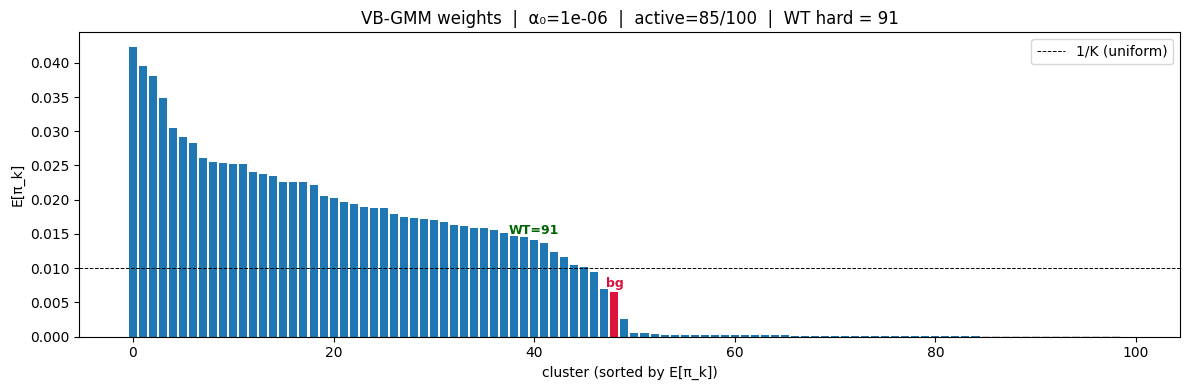

cluster     Nk  Nk_hard   E_pi  active
     37 1058.4     1059 0.0423    True
     32  990.1      990 0.0396    True
     12  952.7      953 0.0381    True
     51  871.7      872 0.0349    True
     10  763.5      763 0.0305    True
     67  728.9      729 0.0292    True
     97  706.9      707 0.0283    True
     15  651.0      651 0.0260    True
     84  637.2      637 0.0255    True
     19  634.8      635 0.0254    True
     94  630.0      630 0.0252    True
     48  629.0      629 0.0252    True
     62  600.2      600 0.0240    True
     61  595.1      595 0.0238    True
     83  586.9      587 0.0235    True
     69  566.3      566 0.0227    True
     80  565.0      565 0.0226    True
     58  564.2      564 0.0226    True
     41  552.0      552 0.0221    True
     79  515.0      515 0.0206    True
      9  504.9      505 0.0202    True
     40  493.0      493 0.0197    True
     31  482.9      483 0.0193    True
     90  472.1      472 0.0189    True
     82  471.0      471 0

In [18]:
## cluster weights — bg highlighted, WT-hard cluster annotated
E_pi  = alpha / alpha.sum()
order = np.argsort(-E_pi)

colors = []
for k in order:
    if k == BG_IDX:        colors.append("crimson")
    elif active[k]:        colors.append("C0")
    else:                  colors.append("lightgray")

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(range(K), E_pi[order], color=colors)
ax.axhline(1/K, ls="--", c="k", lw=0.7, label="1/K (uniform)")

# annotate bg and WT-hard cluster on x-axis
bg_pos = int(np.where(order == BG_IDX)[0][0])
wt_pos = int(np.where(order == k_wt)[0][0])
ax.annotate("bg", (bg_pos, E_pi[BG_IDX]), xytext=(0, 4), textcoords="offset points",
            ha="center", color="crimson", fontsize=9, fontweight="bold")
if k_wt != BG_IDX:
    ax.annotate(f"WT={label(k_wt)}", (wt_pos, E_pi[k_wt]), xytext=(0, 4), textcoords="offset points",
                ha="center", color="darkgreen", fontsize=9, fontweight="bold")

ax.set_xlabel("cluster (sorted by E[π_k])")
ax.set_ylabel("E[π_k]")
ax.set_title(f"VB-GMM weights  |  α₀={alpha0}  |  active={n_active}/{K}  |  WT hard = {label(k_wt)}")
ax.legend(); plt.tight_layout(); plt.show()

hard = log_r.argmax(1)
print(pd.DataFrame({
    "cluster": [label(k) for k in order],
    "Nk":      Nk[order].round(1),
    "Nk_hard": np.bincount(hard, minlength=K)[order],
    "E_pi":    E_pi[order].round(4),
    "active":  active[order],
}).head(min(n_active + 3, K)).to_string(index=False))

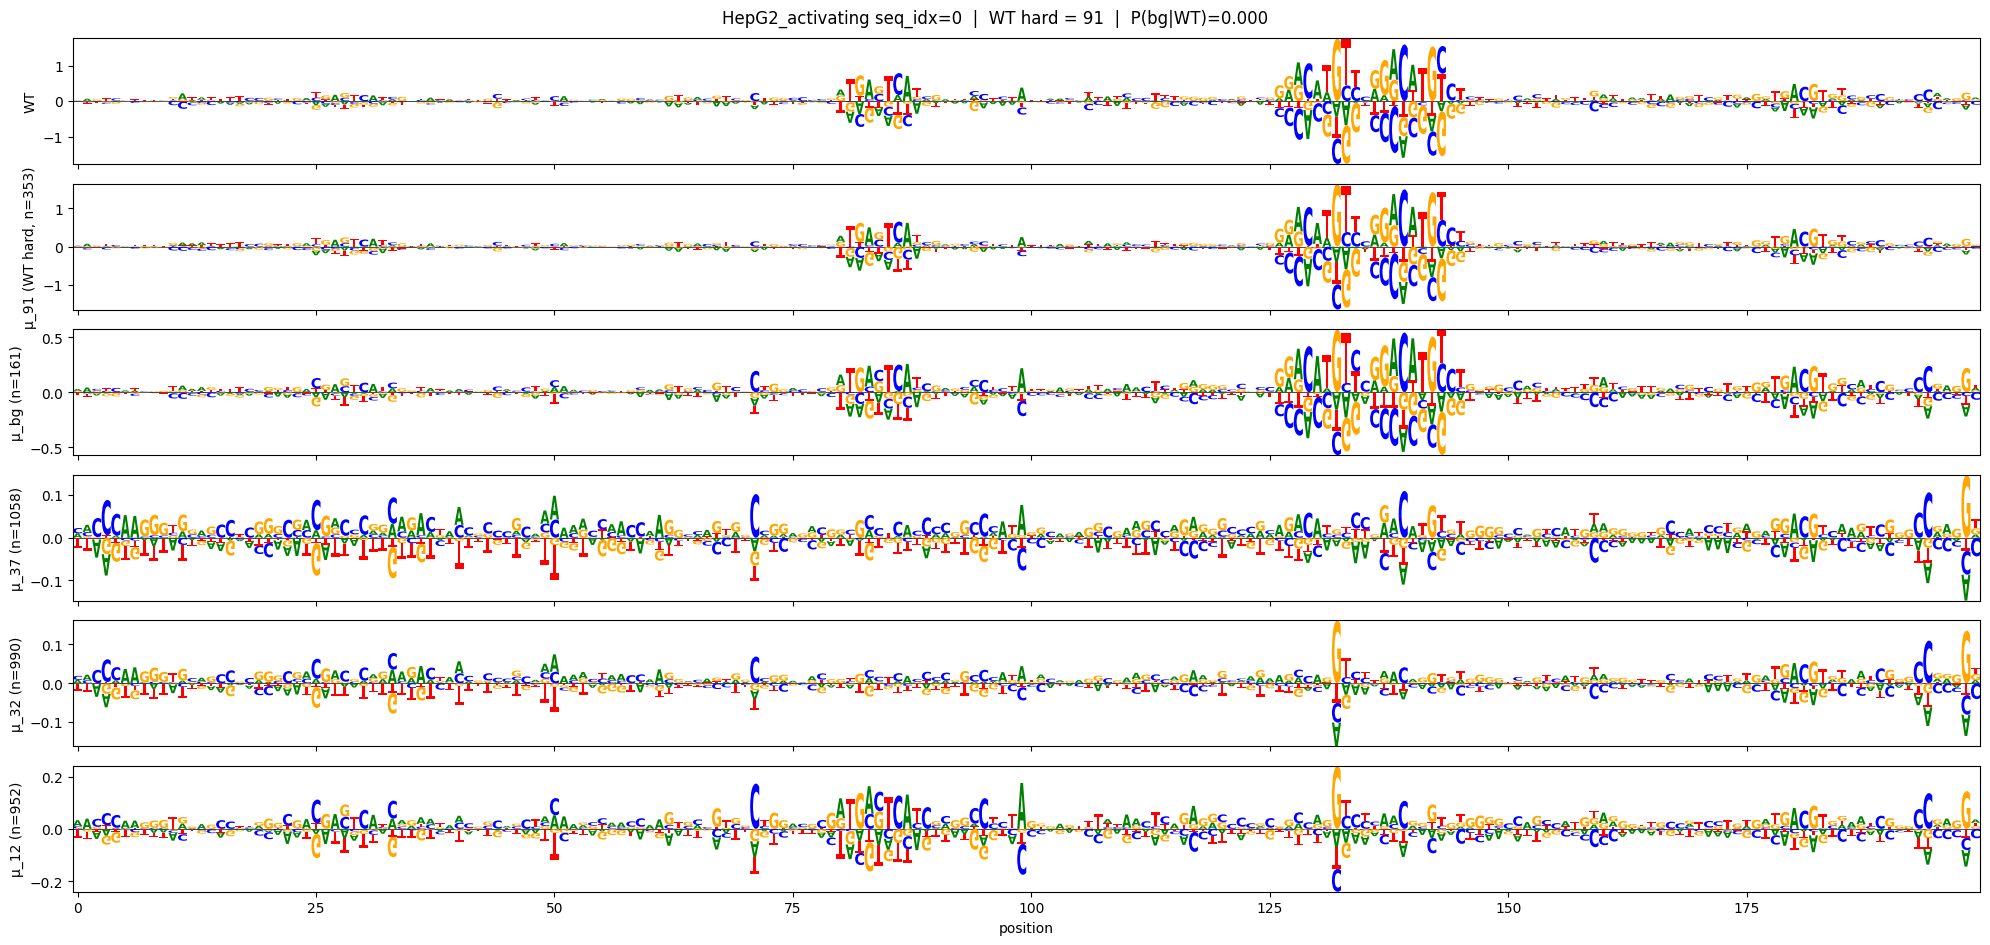

In [19]:
## logos: WT  |  μ of WT's hard cluster  |  μ_bg  |  top active μ's
mu_maps = mu.reshape(K, D // 4, 4)
top     = [k for k in order if active[k] and k != BG_IDX and k != k_wt][:3]
rows    = [("WT",                      wt_attr),
           (f"μ_{label(k_wt)} (WT hard, n={int(Nk[k_wt])})",  mu_maps[k_wt]),
           (f"μ_bg (n={int(Nk[BG_IDX])})",                    mu_maps[BG_IDX])]
rows   += [(f"μ_{k} (n={int(Nk[k])})", mu_maps[k]) for k in top]

fig, axes = plt.subplots(len(rows), 1, figsize=(20, 1.6 * len(rows)), sharex=True)
for ax, (lbl, mat) in zip(axes, rows):
    logomaker.Logo(pd.DataFrame(mat, columns=list("ACGT")), ax=ax)
    ax.set_ylabel(lbl)
axes[-1].set_xlabel("position")
fig.suptitle(f"{condition} seq_idx={seq_idx}  |  WT hard = {label(k_wt)}  |  P(bg|WT)={soft_wt[BG_IDX]:.3f}")
plt.tight_layout(); plt.show()

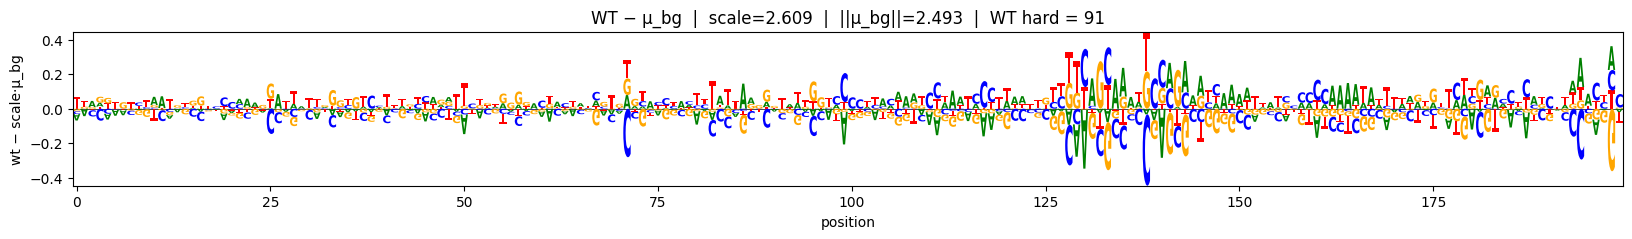

In [20]:
## WT − μ_bg  (Frobenius-scaled bg to match WT magnitude before subtracting)
mu_bg  = mu_maps[BG_IDX]
scale  = np.linalg.norm(wt_attr) / (np.linalg.norm(mu_bg) + 1e-12)
resid  = wt_attr - scale * mu_bg

fig, ax = plt.subplots(figsize=(20, 2))
logomaker.Logo(pd.DataFrame(resid, columns=list("ACGT")), ax=ax)
ax.set_xlabel("position")
ax.set_ylabel("wt − scale·μ_bg")
ax.set_title(f"WT − μ_bg  |  scale={scale:.3f}  |  ||μ_bg||={np.linalg.norm(mu_bg):.3f}  |  WT hard = {label(k_wt)}")
plt.show()